# Breast Cancer Classification Notebook

This notebook trains and evaluates logistic regression models on the breast cancer dataset.

In [19]:
%reset -f

## 1. Import Libraries and Load Data

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
np.random.seed(42)

data = load_breast_cancer()
X = data.data
y = data.target

## 2. Split and Scale Data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Train Models

In [35]:
class LogisticRegressionCustom:

    def __init__(self, lr=0.001, epochs=10, threshold=0.5, logging=False, reg_lambda=0.01, patience=5, batch_size=64):
        self.lr = lr
        self.epochs = epochs
        self.threshold = threshold
        self.logging = logging
        self.eps = 1e-5
        self.reg_lambda = reg_lambda
        self.patience = patience
        self.batch_size = batch_size

    def sigmoid(self, z):
        return np.where(
            z >= 0,
            1 / (1 + np.exp(-z)),       # +ve values
            np.exp(z) / (1 + np.exp(z)) # -ve values
        )

    def score(self, X, y):
        predictions = self.sigmoid(X.dot(self.weights) + self.bias)
        predictions = np.clip(predictions, self.eps, 1 - self.eps)
        return -np.mean(y * np.log2(predictions) + (1 - y) * np.log2(1 - predictions))

    def fit(self, X, y):
        X = X.astype(np.float32)
        y = y.astype(np.float32)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        prev_loss = 0
        early_stopping_counter = 0
        for epoch in range(self.epochs):

            # Shuffle data
            indices = np.random.permutation(n_samples)
            X = X[indices]
            y = y[indices]

            for i in range(0, n_samples, self.batch_size):

                X_batch = X[i:i + self.batch_size]
                y_batch = y[i:i + self.batch_size]
                predictions = self.sigmoid(X_batch.dot(self.weights) + self.bias)
                loss = predictions - y_batch
                self.weights -= self.lr * (X_batch.T.dot(loss) / n_samples + self.reg_lambda * self.weights)
                self.bias -= self.lr * loss.mean()

            bce = self.score(X, y)

            if np.abs(bce - prev_loss) < self.eps:
                if early_stopping_counter < self.patience:
                    early_stopping_counter += 1
                else:
                    break
            else:
                early_stopping_counter = 0
            prev_loss = bce

            if self.logging and epoch % 10 == 0:
                print("epoch:", epoch, "loss:", bce)

    def predict(self, X):
        predictions = self.sigmoid(X.dot(self.weights) + self.bias)
        return np.where(predictions > self.threshold, 1, 0)


In [36]:
clf = LogisticRegressionCustom()
ok = LogisticRegression()
clf.fit(X_train, y_train)
ok.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 4. Evaluation Metrics

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def confusion_matrix_custom(predicts, labels):
    n_classes = len(np.unique(labels))
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)
    precision_vector = np.zeros(n_classes)
    recall_vector = np.zeros(n_classes)
    f1_vector = np.zeros(n_classes)

    for i in range(n_classes):
        for j in range(n_classes):
            confusion_matrix[i][j] = np.sum((predicts == i) & (labels == j))

    for i in range(n_classes):
        precision_vector[i] = confusion_matrix[i][i] / np.sum(confusion_matrix[:, i])
        recall_vector[i] = confusion_matrix[i][i] / np.sum(confusion_matrix[i])
        f1_vector[i] = 2 * precision_vector[i] * recall_vector[i] / (precision_vector[i] + recall_vector[i])

    return confusion_matrix, np.mean(precision_vector), np.mean(recall_vector), np.mean(f1_vector)



Custom Metrics - Custom Model
Precision: 0.9464461185718964
Recall: 0.960472972972973
F1: 0.9526381387619443
Confusion Matrix:


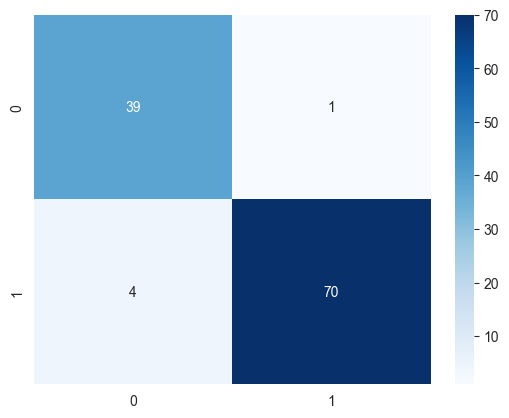

In [38]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(clf.predict(X_test), y_test)
print("Custom Metrics - Custom Model")
sns.heatmap(cm_custom, annot=True, cmap='Blues')
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:")


Custom Metrics - Sklearn Logistic Regression Model
Precision: 0.9697019325253848
Recall: 0.9742063492063492
F1: 0.97186343068696
Confusion Matrix:


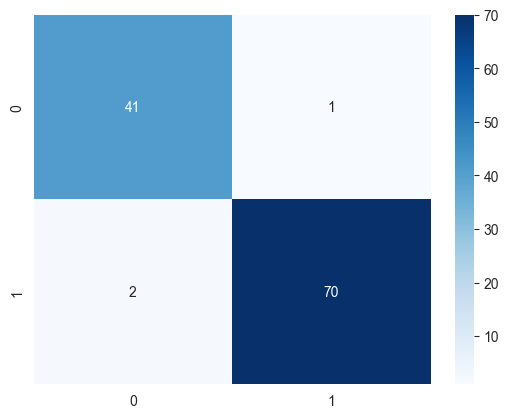

In [27]:
cm_custom, p_custom, r_custom, f1_custom = confusion_matrix_custom(ok.predict(X_test), y_test)
print("Custom Metrics - Sklearn Logistic Regression Model")
sns.heatmap(cm_custom, annot=True, cmap='Blues')
print("Precision:", p_custom)
print("Recall:", r_custom)
print("F1:", f1_custom)
print("Confusion Matrix:")

Sklearn Metrics - Custom Model
Precision: 0.9464461185718964
Recall: 0.960472972972973
F1: 0.9526381387619444
Confusion Matrix:


<Axes: >

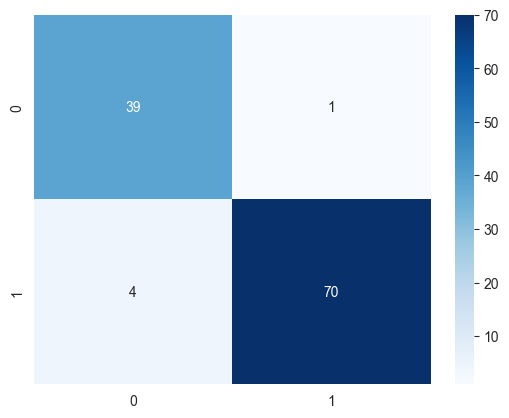

In [9]:
cm_sklearn = confusion_matrix(clf.predict(X_test), y_test)
print("Sklearn Metrics - Custom Model")
print("Precision:", precision_score(clf.predict(X_test), y_test, average='macro'))
print("Recall:", recall_score(clf.predict(X_test), y_test, average='macro'))
print("F1:", f1_score(clf.predict(X_test), y_test, average='macro'))
print("Confusion Matrix:")
sns.heatmap(cm_sklearn, annot=True, cmap='Blues')



Sklearn Metrics - Sklearn Logistic Regression Model
Precision: 0.9697019325253848
Recall: 0.9742063492063492
F1: 0.9718634306869601
Confusion Matrix:


<Axes: >

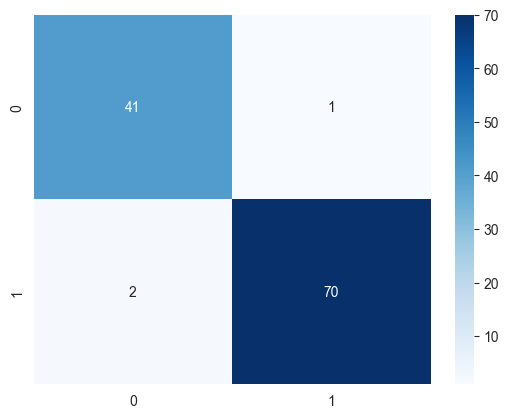

In [10]:
cm_sklearn = confusion_matrix(ok.predict(X_test), y_test)
print("Sklearn Metrics - Sklearn Logistic Regression Model")
print("Precision:", precision_score(ok.predict(X_test), y_test, average='macro'))
print("Recall:", recall_score(ok.predict(X_test), y_test, average='macro'))
print("F1:", f1_score(ok.predict(X_test), y_test, average='macro'))
print("Confusion Matrix:")
sns.heatmap(cm_sklearn, annot=True, cmap='Blues')

